# Fractional Brownian Motion Ensembles

Ensemble simulations that scan H values are used to validate second order moment calculations.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import comparison, fpoints, fcurve
from lib.utils import create_ensemble, apply_to_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nlags = 30
npts = 1023
nsim = 500

def source_plot(H):   
    title = f"Fractional Brownian Motion Ensemble, Ensemble Size={nsim}, H = {format(H, '1.1f')}"
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    t, ensemble = create_ensemble(source, nsim, H=H, npts=npts)
    comparison(ensemble, title=title, xlabel="Time", ylabel=r"$S_t$", lw=1)
    return t, ensemble

def mean_plots(t, ensemble):
    title = "Fractional Brownian Ensemble Mean"
    labels = [r"$\langle \mu_t \rangle$", r"$\mu_t=0$"]
    t_ensemble, ensemble_mean = stats.compute_ensemble_mean(t, ensemble)
    t_fb_mean, fbm_mean = fbm.compute_mean(npts=len(t_ensemble))
    fcurve(data=ensemble_mean, func=fbm_mean, x=t_ensemble, fx=t_fb_mean, title=title, labels=labels, xlabel="Time", ylabel=r"$\mu_t$")    

def sd_plot(t, ensemble, H):
    title = f"Fractional Brownian Ensemble Standard Deviation: H={H}"
    labels = [r"$\langle \sigma_t \rangle$", r"$\sigma_t^H=t^H$"]
    t_ensemble, ensemble_sd = stats.compute_ensemble_sd(t, ensemble)
    t_fbm_sd, fbm_sd = fbm.compute_sd(H=H, Δt=t[-1] / 10, npts=11)
    fpoints(data=ensemble_sd, func=fbm_sd, x=t_ensemble, fx=t_fbm_sd, title=title, labels=labels, xlabel="Time", ylabel=r"$\sigma_t$")
    
def ac_plot(t, ensemble, H):
    title = f"Fractional Brownian Noise Ensemble ACF: H={H}"
    labels = [r"$\langle \rho_\tau \rangle$", r"$\frac{1}{2}[(n - 1)^{2H} + (n + 1)^{2H} - 2n^{2H}]$"]
    func = lambda t, data, **kwargs: stats.compute_ndiff(t, data, **kwargs)
    t_noise, fbm_noise = apply_to_ensemble(func, t, ensemble, ndiff=1)
    ensemble_lag, ensemble_acf = stats.compute_ensemble_acf(t_noise, fbm_noise, nlags=nlags)
    lags, acf = fbm.compute_acf(H=H, nlags=nlags)
    fpoints(data=ensemble_acf, func=acf, x=ensemble_lag, fx=lags, title=title, labels=labels, xlabel=r"$\tau$", ylabel=r"$\rho_t$")


## H=0.5 (Brownian Motion)

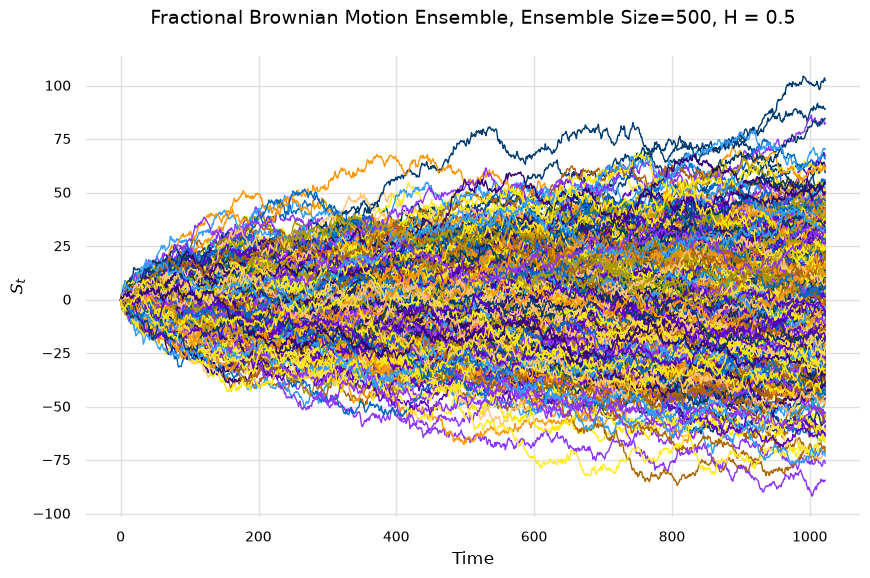

In [3]:
H=0.5
t, ensemble = source_plot(H)

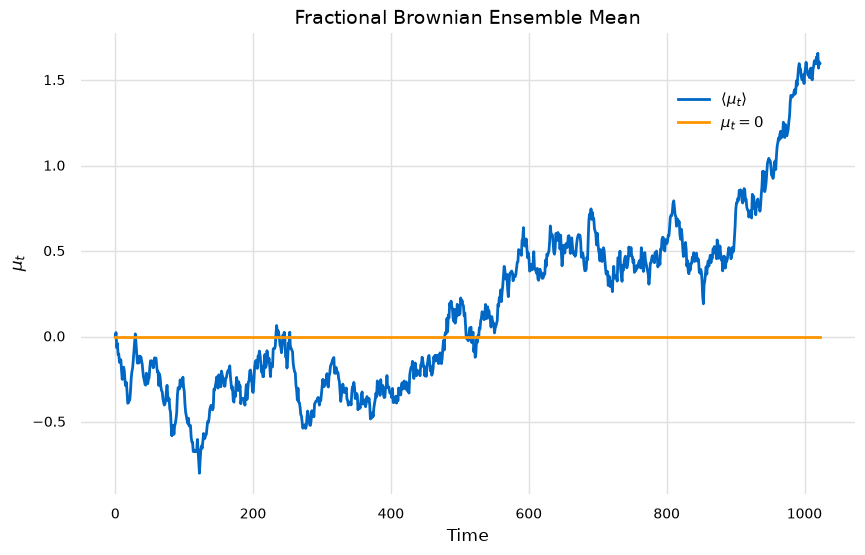

In [4]:
mean_plots(t, ensemble)

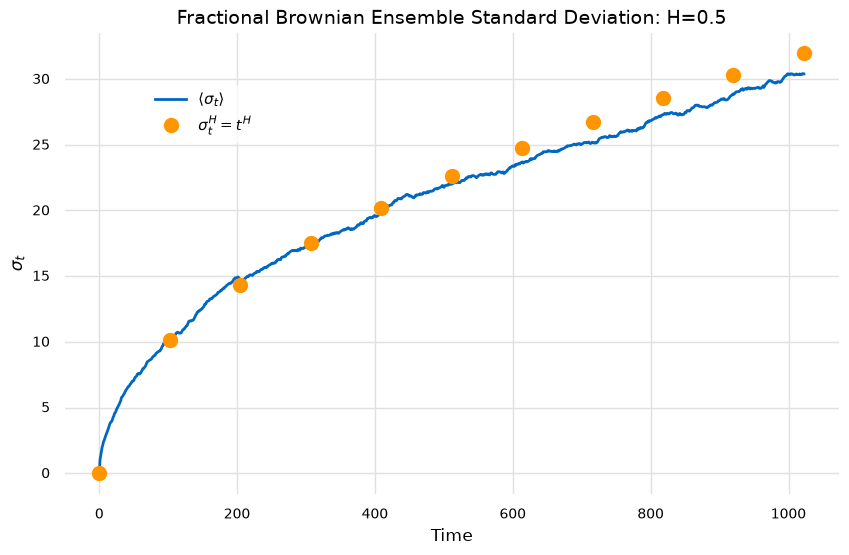

In [5]:
sd_plot(t, ensemble, H)

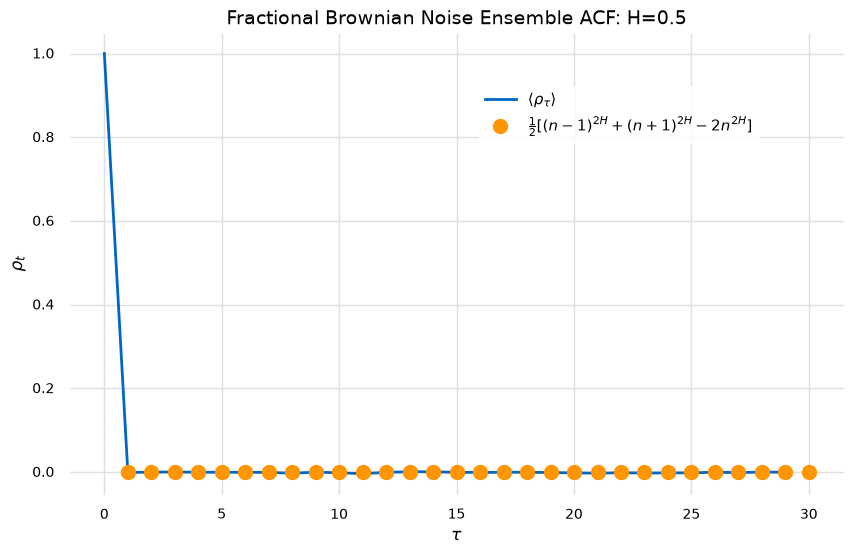

In [6]:
ac_plot(t, ensemble, H)

## H = 0.7

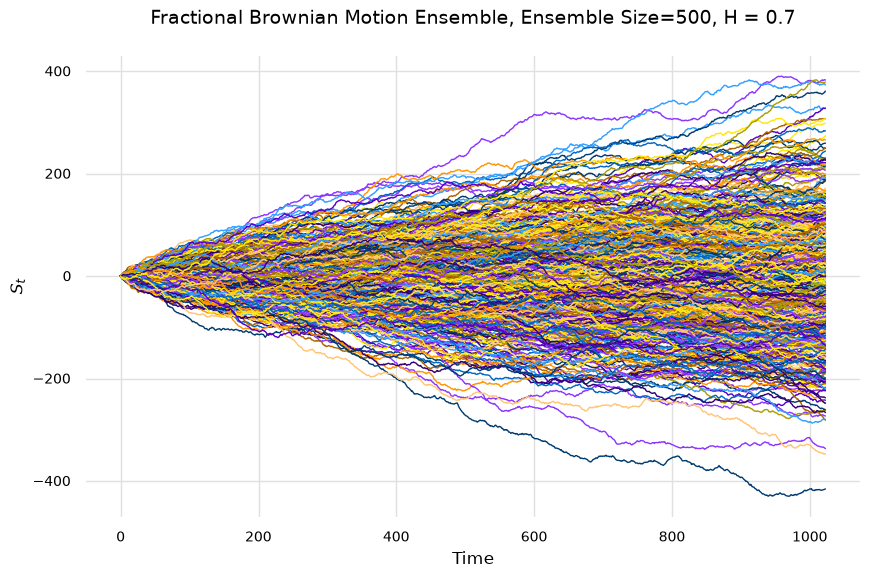

In [7]:
H=0.7
t, ensemble = source_plot(H)

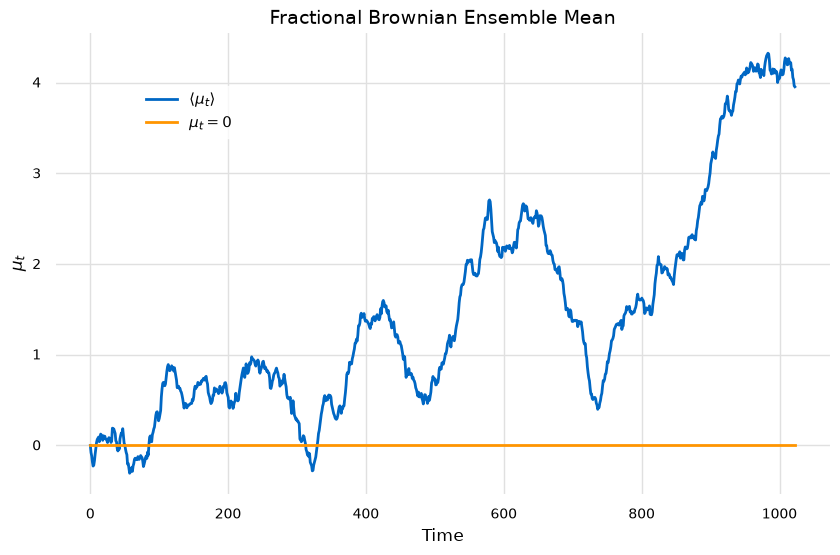

In [8]:
mean_plots(t, ensemble)

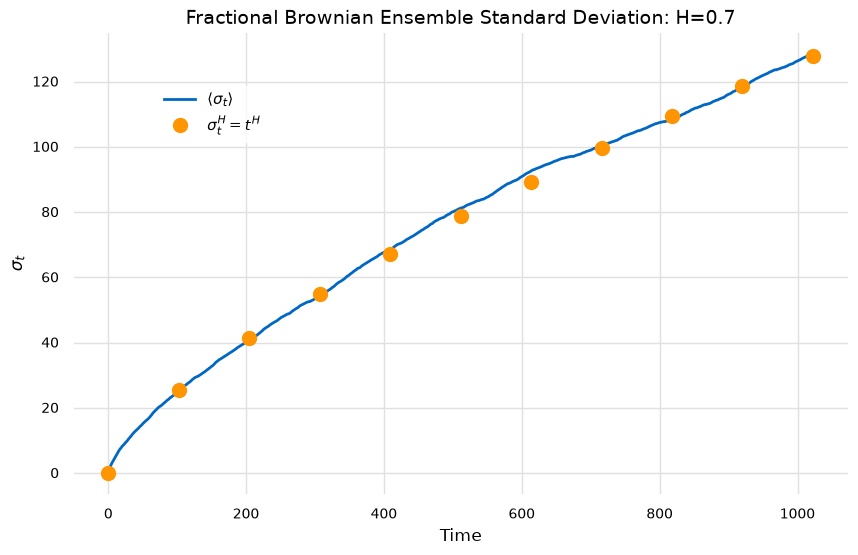

In [9]:
sd_plot(t, ensemble, H)

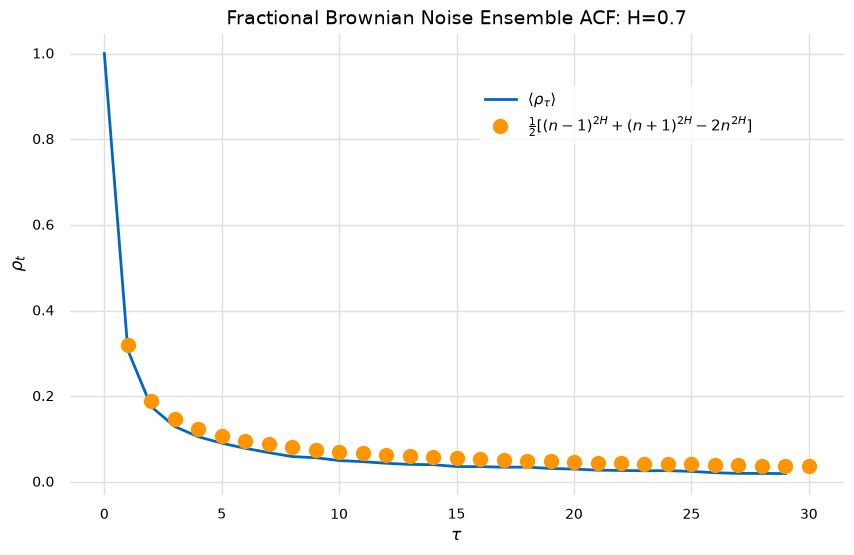

In [10]:
ac_plot(t, ensemble, H)

## H=0.3

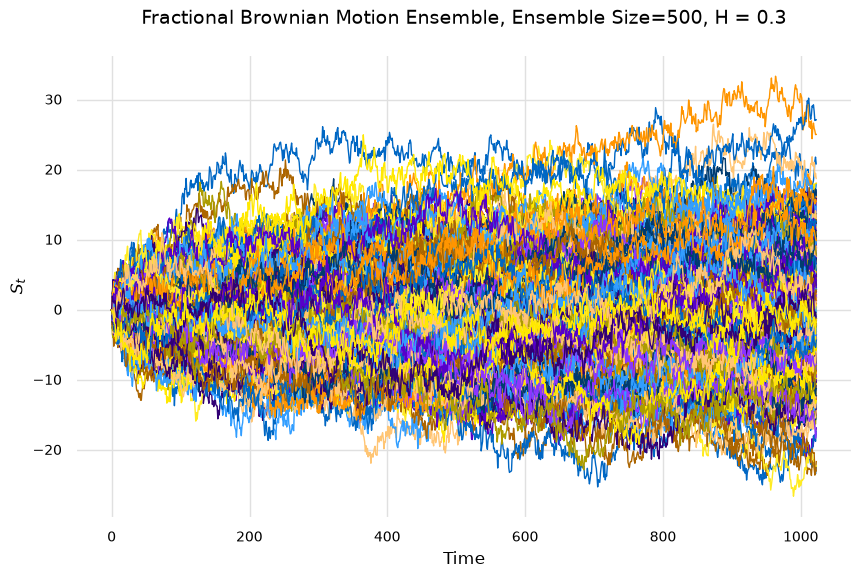

In [11]:
H=0.3
t, ensemble = source_plot(H)

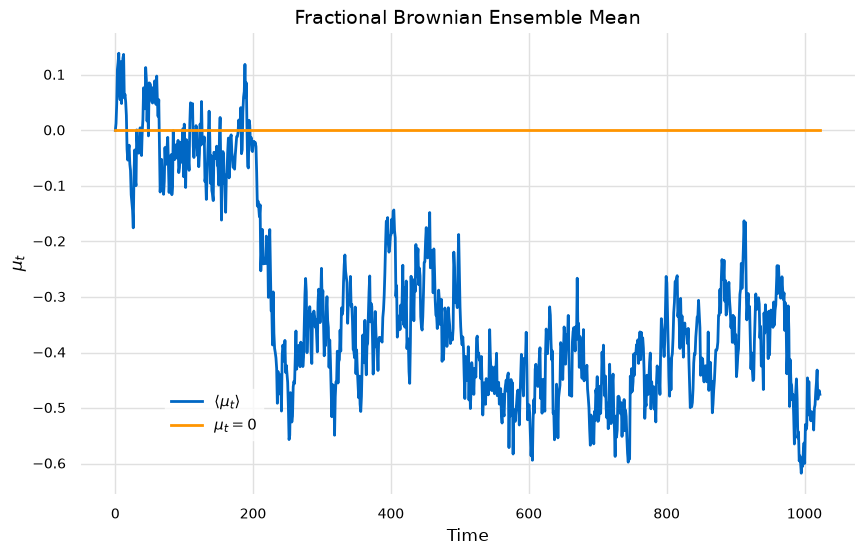

In [12]:
mean_plots(t, ensemble)

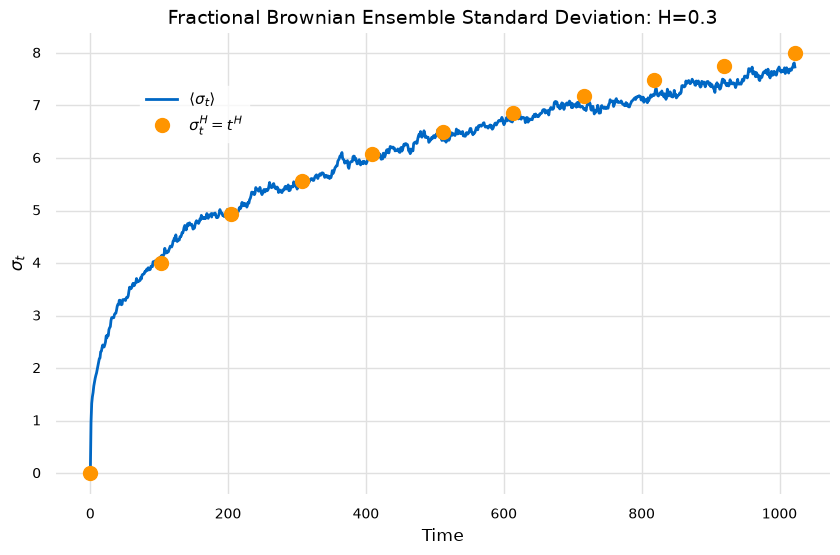

In [13]:
sd_plot(t, ensemble, H)

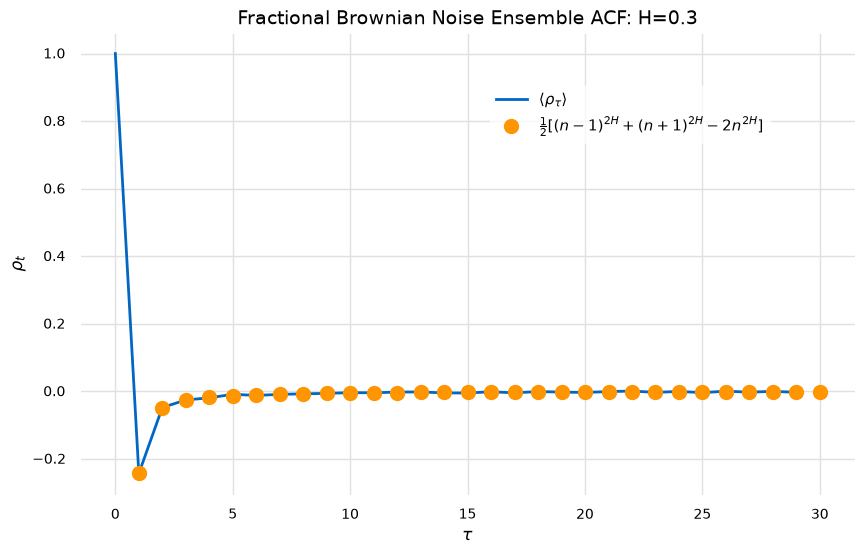

In [14]:
ac_plot(t, ensemble, H)